# Data Minin the Water Table
Predict Which water pumps are faulty to promote clean, portable water accross Tanzania.

In [167]:
# import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce

import geopandas as gpd

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier



### Load the Data

In [2]:
train_values = pd.read_csv("./data/train_values.csv")
train_labels = pd.read_csv("./data/train_labels.csv")
test_labels = pd.read_csv("./data/test_labels.csv")

In [3]:
print(f"Train value data shape: {train_values.shape}")
print(f"Train label data shape: {train_labels.shape}")
print(f"Test label data shape: {test_labels.shape}")

Train value data shape: (59400, 40)
Train label data shape: (59400, 2)
Test label data shape: (14850, 40)


In [5]:
# Preview of the data
print(f"{train_values.head()}\n",)
print(f"{train_labels.head()}\n",)
print(f"{test_labels.head()}\n",)

      id  amount_tsh  ...              waterpoint_type waterpoint_type_group
0  69572      6000.0  ...           communal standpipe    communal standpipe
1   8776         0.0  ...           communal standpipe    communal standpipe
2  34310        25.0  ...  communal standpipe multiple    communal standpipe
3  67743         0.0  ...  communal standpipe multiple    communal standpipe
4  19728         0.0  ...           communal standpipe    communal standpipe

[5 rows x 40 columns]

      id    status_group
0  69572      functional
1   8776      functional
2  34310      functional
3  67743  non functional
4  19728      functional

      id  amount_tsh  ...     waterpoint_type waterpoint_type_group
0  50785         0.0  ...               other                 other
1  51630         0.0  ...  communal standpipe    communal standpipe
2  17168         0.0  ...               other                 other
3  45559         0.0  ...               other                 other
4  49871       500.0  .

In [6]:
# Merge the train values and labels dataframes
train_df = pd.merge(train_values, train_labels, on="id", how="inner")
train_df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


### Exploratory Data Analysis (EDA)

In [7]:
print("Full train data shape: ", train_df.shape)
print("\n", train_df.columns.to_list())

Full train data shape:  (59400, 41)

 ['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height', 'installer', 'longitude', 'latitude', 'wpt_name', 'num_private', 'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga', 'ward', 'population', 'public_meeting', 'recorded_by', 'scheme_management', 'scheme_name', 'permit', 'construction_year', 'extraction_type', 'extraction_type_group', 'extraction_type_class', 'management', 'management_group', 'payment', 'payment_type', 'water_quality', 'quality_group', 'quantity', 'quantity_group', 'source', 'source_type', 'source_class', 'waterpoint_type', 'waterpoint_type_group', 'status_group']


In [ ]:
# data types and non-null count
print("Data info:")
print(train_df.info())

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55763 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int6

In [19]:
# Check for missing values
print("\nMissing values in train data:")
print(train_df.isnull().sum().transpose().reset_index(name="missing_count").sort_values("missing_count", ascending=False))


Missing values in train data:
                    index  missing_count
21            scheme_name          28810
20      scheme_management           3878
5               installer           3655
3                  funder           3637
18         public_meeting           3334
22                 permit           3056
11             subvillage            371
8                wpt_name              2
0                      id              0
7                latitude              0
6               longitude              0
2           date_recorded              0
4              gps_height              0
1              amount_tsh              0
9             num_private              0
10                  basin              0
12                 region              0
16                   ward              0
15                    lga              0
14          district_code              0
13            region_code              0
19            recorded_by              0
17             population 

In [13]:
# Check the distribution of the target variable
print("\nTarget variable distribution:")
print(train_df["status_group"].value_counts(normalize=True))


Target variable distribution:
status_group
functional                 0.543081
non functional             0.384242
functional needs repair    0.072677
Name: proportion, dtype: float64


In [17]:
# show all rows and columns
pd.set_option("display.max_rows", None) # show all rows
print(train_df.info())
pd.reset_option("display.max_rows") # Reset after use

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55763 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

In [20]:
# chech the statistics of the data
train_df.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,59400.000000,59400.000000,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000
mean,37115.131768,317.650385,668.297239,34.077427,-5.706033e+00,0.474141,15.297003,5.629747,179.909983,1300.652475
std,21453.128371,2997.574558,693.116350,6.567432,2.946019e+00,12.236230,17.587406,9.633649,471.482176,951.620547
min,0.000000,0.000000,-90.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18519.750000,0.000000,0.000000,33.090347,-8.540621e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,37061.500000,0.000000,369.000000,34.908743,-5.021597e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,55656.500000,20.000000,1319.250000,37.178387,-3.326156e+00,0.000000,17.000000,5.000000,215.000000,2004.000000
max,74247.000000,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000


In [28]:
# check unique values in cordianl column
cols = ['scheme_management', 'water_quality', 'quantity', 'source']

for col in cols:
    print(f"\nUnique values in {col}:")
    print(train_df[col].unique())


Unique values in scheme_management:
['VWC' 'Other' nan 'Private operator' 'WUG' 'Water Board' 'WUA'
 'Water authority' 'Company' 'Parastatal' 'Trust' 'SWC']

Unique values in water_quality:
['soft' 'salty' 'milky' 'unknown' 'fluoride' 'coloured' 'salty abandoned'
 'fluoride abandoned']

Unique values in quantity:
['enough' 'insufficient' 'dry' 'seasonal' 'unknown']

Unique values in source:
['spring' 'rainwater harvesting' 'dam' 'machine dbh' 'other'
 'shallow well' 'river' 'hand dtw' 'lake' 'unknown']


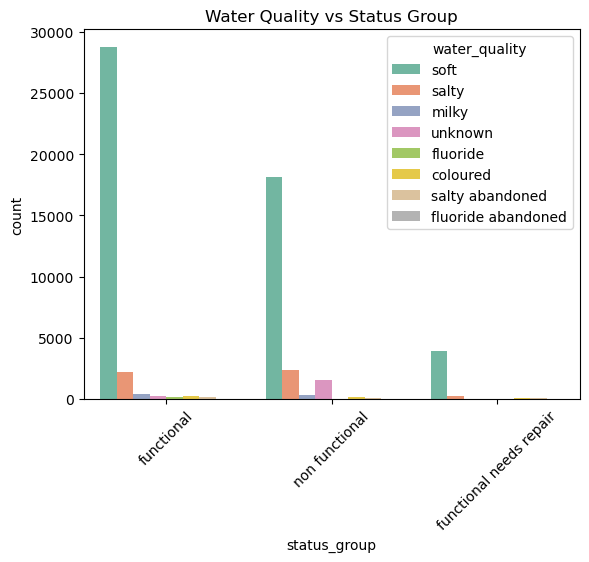

In [30]:
sns.countplot(data=train_df, x="status_group", hue="water_quality", palette="Set2")
plt.xticks(rotation=45)
plt.title("Water Quality vs Status Group")
plt.show();

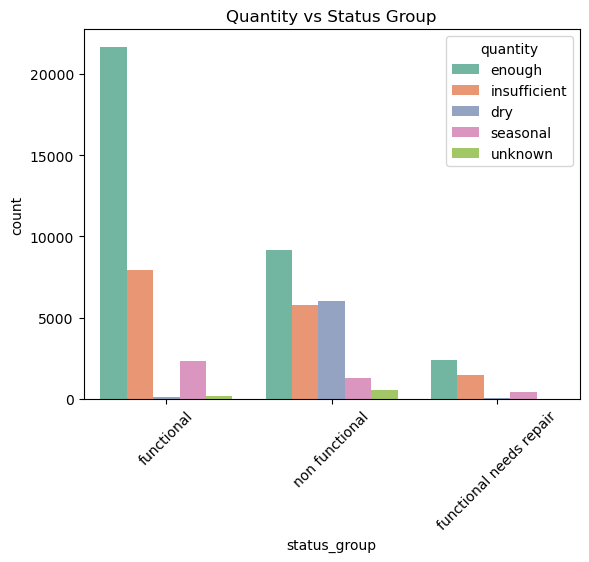

In [31]:
sns.countplot(data=train_df, x="status_group", hue="quantity", palette="Set2")
plt.xticks(rotation=45)
plt.title("Quantity vs Status Group")
plt.show();

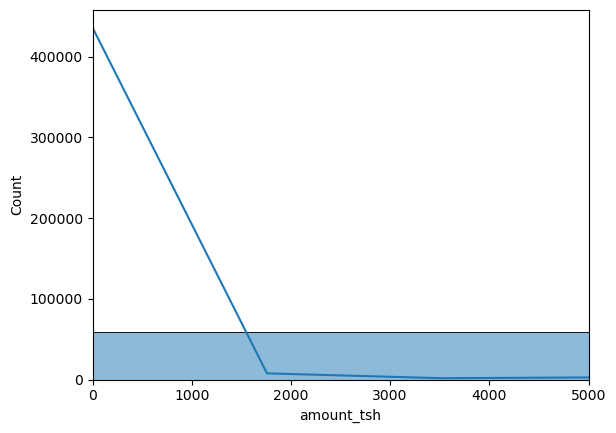

In [ ]:
# Show how much 0s are influencing the amount_tsh column
sns.histplot(train_df["amount_tsh"], bins=50, kde=True)
plt.xlim(0, 5000)
plt.show();

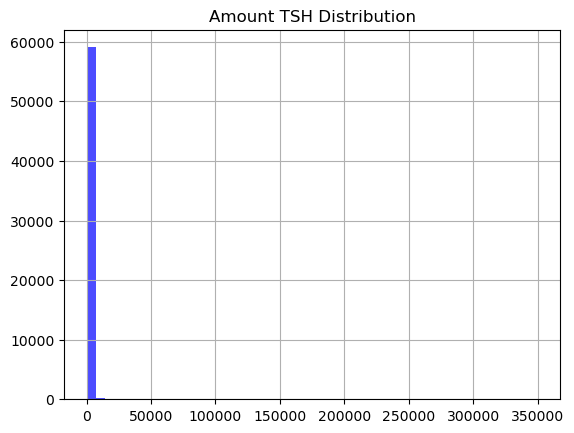

In [ ]:
# plot a simple histogram of the amount_tsh column
train_df["amount_tsh"].hist(bins=50, color="blue", alpha=0.7)
plt.title("Amount TSH Distribution");

In [ ]:
# proportion of each status group in each quantity category
print(pd.crosstab(train_df["quantity"], train_df["status_group"], normalize="index"))

status_group  functional  functional needs repair  non functional
quantity                                                         
dry             0.025136                 0.005924        0.968940
enough          0.652323                 0.072320        0.275357
insufficient    0.523234                 0.095842        0.380924
seasonal        0.574074                 0.102716        0.323210
unknown         0.269962                 0.017744        0.712294


In [78]:
train_df["region"].value_counts().sort_values(ascending=False)

region
Iringa           5294
Shinyanga        4982
Mbeya            4639
Kilimanjaro      4379
Morogoro         4006
Arusha           3350
Kagera           3316
Mwanza           3102
Kigoma           2816
Ruvuma           2640
Pwani            2635
Tanga            2547
Dodoma           2201
Singida          2093
Mara             1969
Tabora           1959
Rukwa            1808
Mtwara           1730
Manyara          1583
Lindi            1546
Dar es Salaam     805
Name: count, dtype: int64

In [ ]:
# check the relationship with amount_tsh and quantity
print(train_df.groupby("quantity")["amount_tsh"].describe())

                count        mean          std  min  25%  50%   75%       max
quantity                                                                     
dry            6246.0  129.408421  1608.109647  0.0  0.0  0.0   0.0  117000.0
enough        33186.0  414.435950  3293.855990  0.0  0.0  0.0  50.0  250000.0
insufficient  15129.0  250.489219  3203.996649  0.0  0.0  0.0  20.0  350000.0
seasonal       4050.0  114.758025   575.884227  0.0  0.0  0.0   0.0   14000.0
unknown         789.0   66.229404   317.152439  0.0  0.0  0.0   0.0    3000.0


In [39]:
# look for zeros or odd values
print(train_df["construction_year"].value_counts().sort_index())

construction_year
0       20709
1960      102
1961       21
1962       30
1963       85
1964       40
1965       19
1966       17
1967       88
1968       77
1969       59
1970      411
1971      145
1972      708
1973      184
1974      676
1975      437
1976      414
1977      202
1978     1037
1979      192
1980      811
1981      238
1982      744
1983      488
1984      779
1985      945
1986      434
1987      302
1988      521
1989      316
1990      954
1991      324
1992      640
1993      608
1994      738
1995     1014
1996      811
1997      644
1998      966
1999      979
2000     2091
2001      540
2002     1075
2003     1286
2004     1123
2005     1011
2006     1471
2007     1587
2008     2613
2009     2533
2010     2645
2011     1256
2012     1084
2013      176
Name: count, dtype: int64


In [ ]:
# Number of Unique funders
print(len(train_df["funder"].unique()))

1897


In [44]:
print((train_df['funder'] == "Unknown").sum()) # check number of unknown funders

4


In [46]:
# Amount_tsh vs status group
train_df.groupby("status_group")["amount_tsh"].describe()

,count,mean,std,min,25%,50%,75%,max
status_group,,,,,,,,
functional,32259.0,461.798235,3889.735284,0.0,0.0,0.0,50.0,350000.0
functional needs repair,4317.0,267.071577,1925.026420,0.0,0.0,0.0,50.0,100000.0
non functional,22824.0,123.481230,1110.120571,0.0,0.0,0.0,0.0,117000.0


In [48]:
# Missing values of all features
print(train_df[['longitude', 'latitude', 'wpt_name', 'num_private', 'basin', 'subvillage', 
                'region', 'region_code', 'district_code', 'lga', 'ward', 'population', 
                'public_meeting', 'recorded_by', 'permit', 'construction_year', 
                'extraction_type', 'extraction_type_group', 'extraction_type_class', 
                'management', 'management_group', 'payment', 'payment_type', 
                'water_quality', 'quality_group', 'quantity_group', 'source', 
                'source_type', 'source_class', 'waterpoint_type', 'waterpoint_type_group']]
      .isnull().sum().sort_values(ascending=False))

public_meeting           3334
permit                   3056
subvillage                371
wpt_name                    2
num_private                 0
latitude                    0
longitude                   0
region                      0
basin                       0
region_code                 0
district_code               0
ward                        0
lga                         0
population                  0
recorded_by                 0
construction_year           0
extraction_type             0
extraction_type_group       0
extraction_type_class       0
management                  0
management_group            0
payment                     0
payment_type                0
water_quality               0
quality_group               0
quantity_group              0
source                      0
source_type                 0
source_class                0
waterpoint_type             0
waterpoint_type_group       0
dtype: int64


In [53]:
# Check for cardinality of categorical features
print("\nCardinality of categorical features (Unique values):\n")
cols = ['wpt_name', 'basin', 'subvillage', 'region', 'lga', 'ward', 'extraction_type', 
        'management', 'payment', 'waterpoint_type', 'recorded_by']
for col in cols:
    print(f"{col}: {train_df[col].nunique()}")


Cardinality of categorical features (Unique values):

wpt_name: 37399
basin: 9
subvillage: 19287
region: 21
lga: 125
ward: 2092
extraction_type: 18
management: 12
payment: 7
waterpoint_type: 7
recorded_by: 1


In [55]:
# Numerique features sumary
print("\nNumerique features summary:\n")
train_df[['longitude', 'latitude', 'num_private', 'population', 'construction_year']].describe()


Numerique features summary:



,longitude,latitude,num_private,population,construction_year
count,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000
mean,34.077427,-5.706033e+00,0.474141,179.909983,1300.652475
std,6.567432,2.946019e+00,12.236230,471.482176,951.620547
min,0.000000,-1.164944e+01,0.000000,0.000000,0.000000
25%,33.090347,-8.540621e+00,0.000000,0.000000,0.000000
50%,34.908743,-5.021597e+00,0.000000,25.000000,1986.000000
75%,37.178387,-3.326156e+00,0.000000,215.000000,2004.000000
max,40.345193,-2.000000e-08,1776.000000,30500.000000,2013.000000


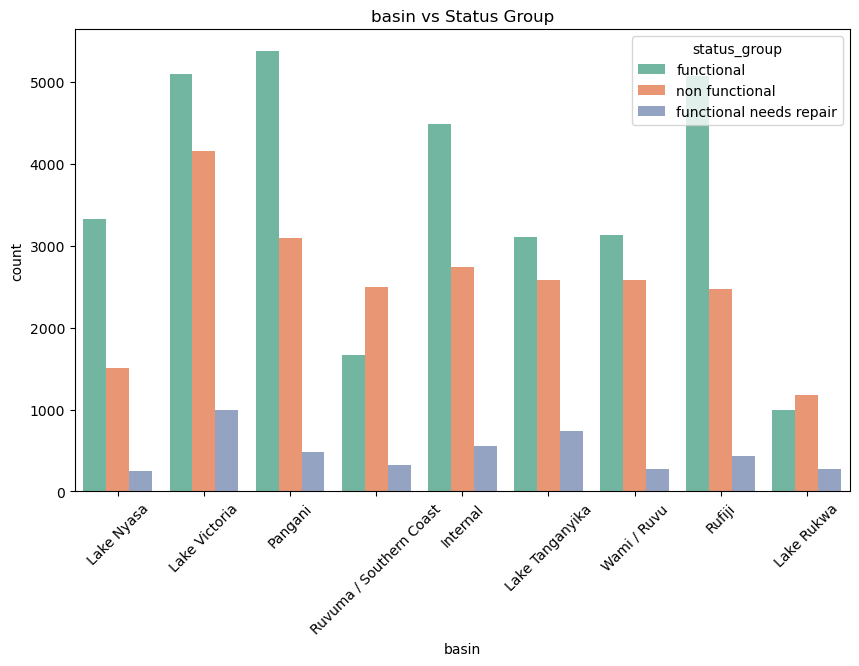

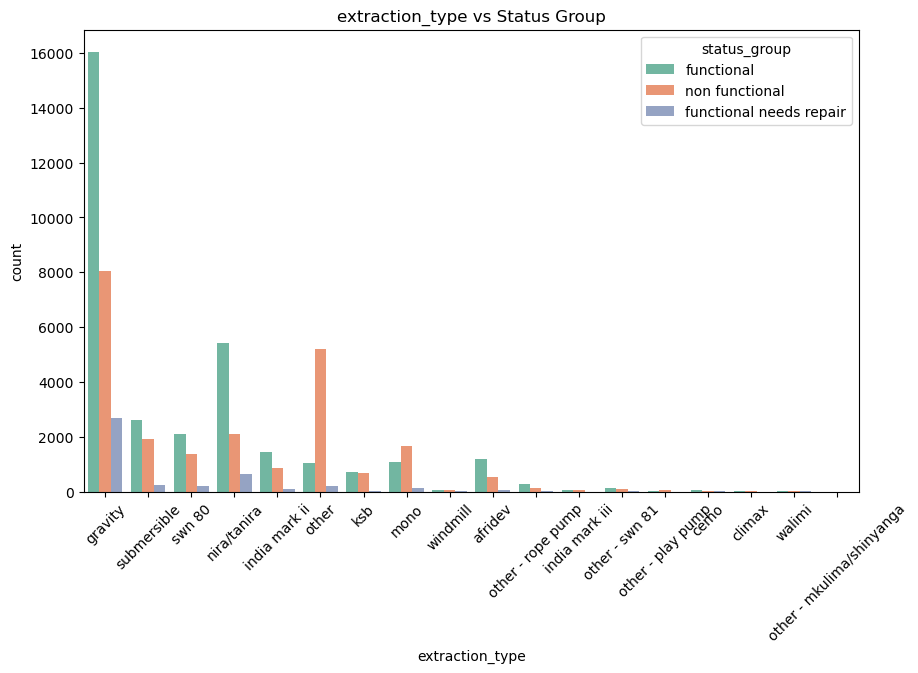

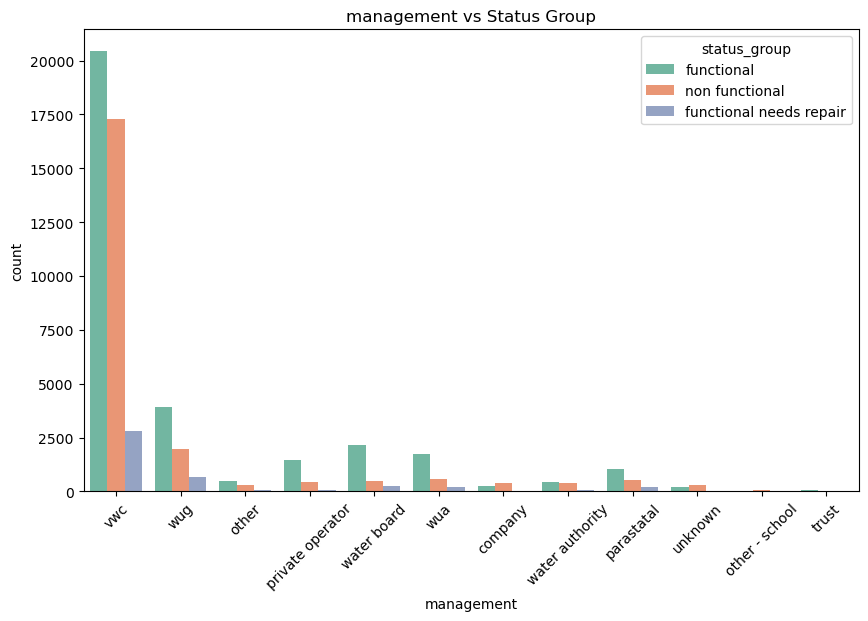

In [61]:
# Categorical vs status_group

for col in ['basin', 'extraction_type', 'management']:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=col, hue="status_group", data=train_df, palette="Set2")
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Status Group")
    plt.show()

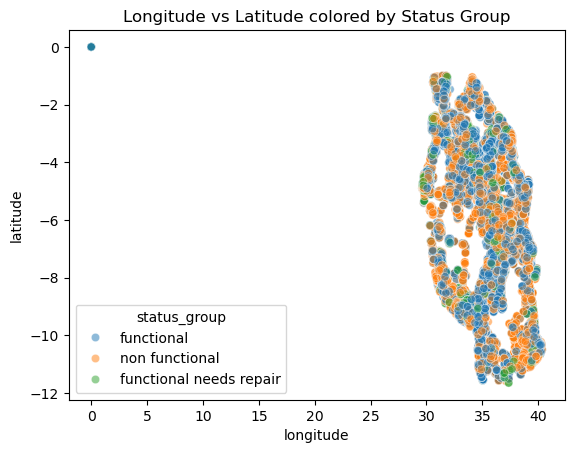

In [62]:
# Scatter plot of longitude/latitude colored by status_group
sns.scatterplot(data=train_df, x="longitude", y="latitude", hue="status_group", alpha=0.5)
plt.title("Longitude vs Latitude colored by Status Group")
plt.show()

In [64]:
# check the values of public_meeting and permit
print(train_df["public_meeting"].value_counts(dropna=False))
print(train_df["permit"].value_counts(dropna=False))

public_meeting
True     51011
False     5055
NaN       3334
Name: count, dtype: int64
permit
True     38852
False    17492
NaN       3056
Name: count, dtype: int64


In [66]:
print((train_df["longitude"] == 0).sum())

1812


In [67]:
print((train_df['latitude'] >= 0).sum())

0


In [68]:
print((train_df['num_private'] > 0).sum())

757


In [69]:
print(train_df['population'].describe())

count    59400.000000
mean       179.909983
std        471.482176
min          0.000000
25%          0.000000
50%         25.000000
75%        215.000000
max      30500.000000
Name: population, dtype: float64


In [70]:
train_df["extraction_type"].value_counts()

extraction_type
gravity                      26780
nira/tanira                   8154
other                         6430
submersible                   4764
swn 80                        3670
mono                          2865
india mark ii                 2400
afridev                       1770
ksb                           1415
other - rope pump              451
other - swn 81                 229
windmill                       117
india mark iii                  98
cemo                            90
other - play pump               85
walimi                          48
climax                          32
other - mkulima/shinyanga        2
Name: count, dtype: int64

In [71]:
train_df["management"].value_counts()

management
vwc                 40507
wug                  6515
water board          2933
wua                  2535
private operator     1971
parastatal           1768
water authority       904
other                 844
company               685
unknown               561
other - school         99
trust                  78
Name: count, dtype: int64

In [72]:
print(pd.crosstab(train_df['basin'], train_df['status_group'], normalize='index'))

status_group             functional  functional needs repair  non functional
basin                                                                       
Internal                   0.575723                 0.071548        0.352730
Lake Nyasa                 0.653687                 0.049164        0.297148
Lake Rukwa                 0.407498                 0.110024        0.482478
Lake Tanganyika            0.483053                 0.115361        0.401586
Lake Victoria              0.497658                 0.096507        0.405835
Pangani                    0.600895                 0.053356        0.345749
Rufiji                     0.635406                 0.054789        0.309804
Ruvuma / Southern Coast    0.371689                 0.072557        0.555753
Wami / Ruvu                0.523802                 0.044931        0.431268


In [73]:
# Check for redundancy
print(train_df['quantity'].equals(train_df['quantity_group']))

True


### Data Preprocessing

In [74]:
# Give test data a valuable name
test_df = test_labels.copy()
test_df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,50785,0.0,2013-02-04,Dmdd,1996,DMDD,35.290799,-4.059696,Dinamu Secondary School,0,Internal,Magoma,Manyara,21,3,Mbulu,Bashay,321,True,GeoData Consultants Ltd,Parastatal,NaN,True,2012,other,other,other,parastatal,parastatal,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,other,other
1,51630,0.0,2013-02-04,Government Of Tanzania,1569,DWE,36.656709,-3.309214,Kimnyak,0,Pangani,Kimnyak,Arusha,2,2,Arusha Rural,Kimnyaki,300,True,GeoData Consultants Ltd,VWC,TPRI pipe line,True,2000,gravity,gravity,gravity,vwc,user-group,never pay,never pay,soft,good,insufficient,insufficient,spring,spring,groundwater,communal standpipe,communal standpipe
2,17168,0.0,2013-02-01,NaN,1567,NaN,34.767863,-5.004344,Puma Secondary,0,Internal,Msatu,Singida,13,2,Singida Rural,Puma,500,True,GeoData Consultants Ltd,VWC,P,NaN,2010,other,other,other,vwc,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,other,other
3,45559,0.0,2013-01-22,Finn Water,267,FINN WATER,38.058046,-9.418672,Kwa Mzee Pange,0,Ruvuma / Southern Coast,Kipindimbi,Lindi,80,43,Liwale,Mkutano,250,NaN,GeoData Consultants Ltd,VWC,NaN,True,1987,other,other,other,vwc,user-group,unknown,unknown,soft,good,dry,dry,shallow well,shallow well,groundwater,other,other
4,49871,500.0,2013-03-27,Bruder,1260,BRUDER,35.006123,-10.950412,Kwa Mzee Turuka,0,Ruvuma / Southern Coast,Losonga,Ruvuma,10,3,Mbinga,Mbinga Urban,60,NaN,GeoData Consultants Ltd,Water Board,BRUDER,True,2000,gravity,gravity,gravity,water board,user-group,pay monthly,monthly,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe


In [75]:
# put all columns to drop in a list
cols_to_drop = ['amount_tsh', 'funder', 'extraction_type_group', 'extraction_type_class', 
                'management_group', 'payment_type', 'quantity_group', 'source_type', 
                'source_class', 'waterpoint_type_group', 'wpt_name', 'recorded_by', 
                'num_private', 'subvillage', 'ward', 'lga']

In [76]:
# drop columns from train and test data
train_df = train_df.drop(columns=cols_to_drop)

test_df = test_df.drop(columns=cols_to_drop)

print("Train shape after dropping:", train_df.shape)
print("Test shape after dropping:", test_df.shape)

Train shape after dropping: (59400, 25)
Test shape after dropping: (14850, 24)


In [79]:
# Impute binary features with model "True"
for df in [train_df, test_df]:
    df["public_meeting"] = df["public_meeting"].fillna("True")
    df["permit"] = df["permit"].fillna("True")

In [82]:
# Impute categorical features with model "Unknown"
for df in [train_df, test_df]:
    df["water_quality"] = df["water_quality"].fillna("Unknown")
    df["management"] = df["management"].fillna("Unknown")
    df["payment"] = df["payment"].fillna("Unknown")
    df["source"] = df["source"].fillna("Unknown")
    df["waterpoint_type"] = df["waterpoint_type"].fillna("Unknown")
    df["scheme_management"] = df["scheme_management"].fillna("Unknown")
    df["installer"] = df["installer"].fillna("Unknown")

In [83]:
# Drop 'scheme_name'
train_df = train_df.drop(columns="scheme_name")
test_df = test_df.drop(columns='scheme_name')

In [84]:
# Impute longitude zeros with median by region
for df in [train_df, test_df]:
    median_long_by_region = df[df['longitude'] != 0].groupby('region')['longitude'].median()
    df['longitude'] = df.apply(
        lambda row: median_long_by_region[row['region']] if row['longitude'] == 0 else row['longitude'], 
        axis=1
    )

In [87]:
# Check any other missing values
print("Train missing values:\n", (train_df.isnull().sum().sort_values(ascending=False)).head())
print("Test missing values:\n", (test_df.isnull().sum().sort_values(ascending=False)).head())

Train missing values:
 id               0
date_recorded    0
gps_height       0
installer        0
longitude        0
dtype: int64
Test missing values:
 id               0
date_recorded    0
gps_height       0
installer        0
longitude        0
dtype: int64


In [88]:
# Check median construction year by region (non-zero only)
train_df[train_df['construction_year'] != 0].groupby('region')['construction_year'].median()

region
Arusha           2001.0
Dar es Salaam    2000.0
Iringa           2000.0
Kigoma           2001.0
Kilimanjaro      2002.0
Lindi            1997.0
Manyara          2004.0
Mara             1998.0
Morogoro         1997.0
Mtwara           1988.0
Mwanza           1996.0
Pwani            2007.0
Rukwa            1988.0
Ruvuma           1997.0
Shinyanga        2005.0
Singida          2000.0
Tanga            1996.0
Name: construction_year, dtype: float64

In [ ]:
# This shows error because we condition the median on the region, but the region it has null values
for df in [train_df, test_df]:
    median_year_by_region = df[df['construction_year'] != 0].groupby('region')['construction_year'].median()
    df['construction_year'] = df.apply(
        lambda row: median_year_by_region[row['region']] if row['construction_year'] == 0 else row['construction_year'], 
        axis=1
    )

KeyError: 'Kagera'

In [ ]:
# Check regions with all construction_year == 0
zero_year_regions = train_df[train_df['construction_year'] == 0]['region'].value_counts()
print("Regions with all zeros in train_df:\n", zero_year_regions)

# Compare with all regions
all_regions = train_df['region'].unique()
print("\nAll regions in train_df:", all_regions)

Regions with all zeros in train_df:
 region
Shinyanga        4818
Mbeya            4639
Kagera           3316
Mwanza           2747
Dodoma           2201
Tabora           1959
Iringa            372
Pwani             176
Lindi             113
Tanga              94
Mtwara             87
Arusha             51
Kilimanjaro        35
Morogoro           18
Dar es Salaam      17
Mara               17
Ruvuma             16
Manyara            13
Kigoma             10
Singida             8
Rukwa               2
Name: count, dtype: int64

All regions in train_df: ['Iringa' 'Mara' 'Manyara' 'Mtwara' 'Kagera' 'Tanga' 'Shinyanga' 'Tabora'
 'Pwani' 'Ruvuma' 'Kilimanjaro' 'Rukwa' 'Mwanza' 'Kigoma' 'Lindi' 'Dodoma'
 'Arusha' 'Mbeya' 'Singida' 'Morogoro' 'Dar es Salaam']


In [93]:
for df in [train_df, test_df]:
    # Global median for fallback
    global_median = df[df['construction_year'] != 0]['construction_year'].median()
    # Median by region, fill NaN with global median
    median_year_by_region = df[df['construction_year'] != 0].groupby('region')['construction_year'].median().reindex(df['region'].unique(), fill_value=global_median)
    df['construction_year'] = df.apply(
        lambda row: median_year_by_region[row['region']] if row['construction_year'] == 0 else row['construction_year'],
        axis=1
    )

In [94]:
# Construction year after imputation
print("Train construction year after imputation:\n", train_df['construction_year'].describe())
print("Test construction year after imputation:\n", test_df['construction_year'].describe())

Train construction year after imputation:
 count    59400.000000
mean      1998.137290
std         10.375139
min       1960.000000
25%       1995.000000
50%       2000.000000
75%       2005.000000
max       2013.000000
Name: construction_year, dtype: float64
Test construction year after imputation:
 count    14850.000000
mean      1998.412862
std         10.183625
min       1960.000000
25%       1996.000000
50%       2000.000000
75%       2005.000000
max       2013.000000
Name: construction_year, dtype: float64


In [95]:
for df in [train_df, test_df]:
    df["pump_age"] = pd.to_datetime(df["date_recorded"]).dt.year - df["construction_year"]
    # enure pump_age is non-negative
    df["pump_age"] = df["pump_age"].apply(lambda x: max(x, 0))

# drop "date_recorded" column
train_df = train_df.drop(columns=["date_recorded"])
test_df = test_df.drop(columns=["date_recorded"])

In [96]:
# Check stats
print("Train pump_age stats:\n", train_df['pump_age'].describe())
print("Test pump_age stats:\n", test_df['pump_age'].describe())

Train pump_age stats:
 count    59400.000000
mean        13.785084
std         10.428538
min          0.000000
25%          7.000000
50%         11.000000
75%         16.000000
max         53.000000
Name: pump_age, dtype: float64
Test pump_age stats:
 count    14850.000000
mean        13.494209
std         10.245258
min          0.000000
25%          7.000000
50%         11.000000
75%         16.000000
max         53.000000
Name: pump_age, dtype: float64


In [100]:
# One-hot encoding
one_hot_cols = ['basin', 'payment', 'waterpoint_type', 'scheme_management', 
                'extraction_type', 'management', 'water_quality', 'quality_group', 
                'quantity', 'source']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_df[one_hot_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [101]:
# Transform train and test
train_one_hot = pd.DataFrame(encoder.transform(train_df[one_hot_cols]), 
                            columns=encoder.get_feature_names_out(), index=train_df.index)
test_one_hot = pd.DataFrame(encoder.transform(test_df[one_hot_cols]), 
                           columns=encoder.get_feature_names_out(), index=test_df.index)

In [102]:
# Drop original columns and concatenate
train_df = pd.concat([train_df.drop(columns=one_hot_cols), train_one_hot], axis=1)
test_df = pd.concat([test_df.drop(columns=one_hot_cols), test_one_hot], axis=1)

In [103]:
# Verify installer is still there
print("Installer in train:", 'installer' in train_df.columns)

Installer in train: True


In [111]:
# Final shapes
print("Train shape after encoding:", train_df.shape)
print("Test shape after encoding:", test_df.shape)

Train shape after encoding: (59400, 108)
Test shape after encoding: (14850, 107)


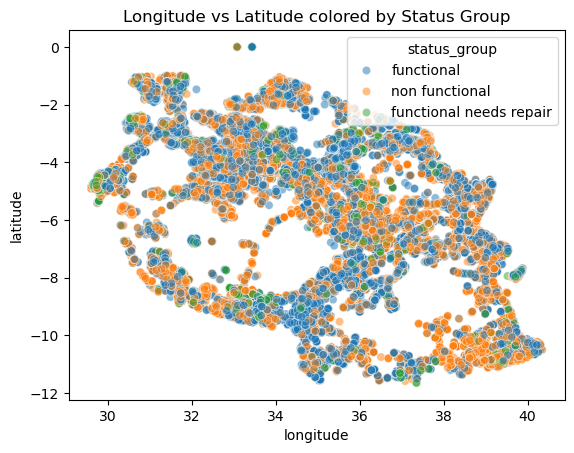

In [113]:
# Scatter plot of longitude/latitude colored by status_group
sns.scatterplot(data=train_df, x="longitude", y="latitude", hue="status_group", alpha=0.5)
plt.title("Longitude vs Latitude colored by Status Group")
plt.show()

In [118]:
# need to encode the region and installer columns
# Since RandomForestClassifier can handle categorical variables, we can use LabelEncoder for these two columns

for col in ['installer', 'region']:
    le = LabelEncoder()
    # Fit on train_df and transform both train and test
    train_df[col] = le.fit_transform(train_df[col])
    # Handle test_df: map known labels, assign a new label for unseen categories
    test_df[col] = test_df[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else len(le.classes_))

print("Train shape after encoding:", train_df.shape)
print("Test shape after encoding:", test_df.shape)
print("Sample installer values (train):", train_df['installer'].head().tolist())
print("Sample region values (train):", train_df['region'].head().tolist())

Train shape after encoding: (59400, 108)
Test shape after encoding: (14850, 107)
Sample installer values (train): [1518, 545, 2048, 1852, 119]
Sample region values (train): [3, 9, 8, 12, 4]


In [123]:
# conver true and false column to 1s and 0s
for df in [train_df, test_df]:
    df["public_meeting"] = df["public_meeting"].map({"True": 1, "False": 0})
    df["permit"] = df["permit"].map({"True": 1, "False": 0})

### Split Train Data

In [124]:
# Features and target
X = train_df.drop(columns=["id", "status_group"])
y = train_df["status_group"]

# stratified split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("X_train shape: ", X_train.shape)
print("X_val shape: ", X_val.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_val distribution:\n", y_val.value_counts(normalize=True))

X_train shape:  (47520, 106)
X_val shape:  (11880, 106)
y_train distribution:
 status_group
functional                 0.543077
non functional             0.384238
functional needs repair    0.072685
Name: proportion, dtype: float64
y_val distribution:
 status_group
functional                 0.543098
non functional             0.384259
functional needs repair    0.072643
Name: proportion, dtype: float64


In [125]:
# Class weights (inverse frequency)
class_weights = {
    "functional": 1 / 0.543081,
    "non functional": 1 / 0.3584242,
    "functional needs repair": 1 / 0.072677,
}

## Build Model

In [126]:
# Initialize and train
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight=class_weights
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight={'functional': 1.8413459502357843,
                                     'functional needs repair': 13.759511262159966,
                                     'non functional': 2.7899901848145294},
                       random_state=42)

In [127]:
# predict
y_pred = rf.predict(X_val)

In [128]:
# Evaluate
print("Accuracy Score:", accuracy_score(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))

Accuracy Score: 0.8017676767676768
Classification Report:
                          precision    recall  f1-score   support

             functional       0.81      0.88      0.84      6452
functional needs repair       0.49      0.35      0.41       863
         non functional       0.83      0.78      0.81      4565

               accuracy                           0.80     11880
              macro avg       0.71      0.67      0.68     11880
           weighted avg       0.80      0.80      0.80     11880



In [131]:
# Feature importance
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
})
print(importances.sort_values("importance", ascending=False).head(10))

              feature  importance
2           longitude    0.145007
3            latitude    0.142387
0          gps_height    0.069780
91       quantity_dry    0.053317
7          population    0.048027
1           installer    0.047448
11           pump_age    0.044530
10  construction_year    0.040618
6       district_code    0.031336
4              region    0.022168


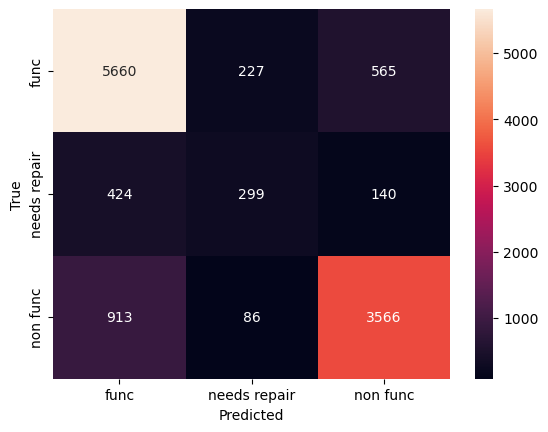

In [132]:

cm = confusion_matrix(y_val, y_pred, labels=["functional", "functional needs repair", "non functional"])
sns.heatmap(cm, annot=True, fmt="d", xticklabels=['func', 'needs repair', 'non func'], yticklabels=['func', 'needs repair', 'non func'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [133]:
confusion_matrix(y_val, y_pred)

array([[5660,  227,  565],
       [ 424,  299,  140],
       [ 913,   86, 3566]])

### Iterate by Tunnig the RandomForestClassifier Model

In [135]:
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weights,
    max_depth=15,
    min_samples_split=5,
    )

rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight={'functional': 1.8413459502357843,
                                     'functional needs repair': 13.759511262159966,
                                     'non functional': 2.7899901848145294},
                       max_depth=15, min_samples_split=5)

In [136]:
# predict the tuned
y_pred_tuned = rf_tuned.predict(X_val)
print("Tunned Accuracy Score: ", accuracy_score(y_val, y_pred_tuned))
print("Tunned Classification report:\n", classification_report(y_val, y_pred_tuned))

Tunned Accuracy Score:  0.7504208754208754
Tunned Classification report:
                          precision    recall  f1-score   support

             functional       0.82      0.77      0.80      6452
functional needs repair       0.31      0.64      0.42       863
         non functional       0.84      0.74      0.79      4565

               accuracy                           0.75     11880
              macro avg       0.66      0.72      0.67     11880
           weighted avg       0.79      0.75      0.77     11880



In [138]:
# confirm 80% isn't a fluke
scores = cross_val_score(rf, X, y, cv=5, scoring="accuracy")
print("Cross-val Accuracy: mean =", scores.mean(), "std =", scores.std())

Cross-val Accuracy: mean = 0.8023232323232324 std = 0.003887613299623458


### Second Tuning

In [139]:
rf_tuned2 = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weights,
    max_depth=25,
    min_samples_leaf=2,
    random_state=42   
)

rf_tuned2.fit(X_train, y_train)

RandomForestClassifier(class_weight={'functional': 1.8413459502357843,
                                     'functional needs repair': 13.759511262159966,
                                     'non functional': 2.7899901848145294},
                       max_depth=25, min_samples_leaf=2, random_state=42)

In [140]:
# predict the tuned
y_pred_tuned2 = rf_tuned2.predict(X_val)
# Evaluate
print("Tunned2 Accuracy Score: ", accuracy_score(y_val, y_pred_tuned2))
print("Tunned2 Classification report:\n", classification_report(y_val, y_pred_tuned2))

Tunned2 Accuracy Score:  0.7833333333333333
Tunned2 Classification report:
                          precision    recall  f1-score   support

             functional       0.83      0.82      0.82      6452
functional needs repair       0.37      0.56      0.45       863
         non functional       0.84      0.78      0.81      4565

               accuracy                           0.78     11880
              macro avg       0.68      0.72      0.69     11880
           weighted avg       0.80      0.78      0.79     11880



### Iterate to Smote

In [147]:
# First we need to drop permit and public meeting
X_train = X_train.drop(columns=["permit", "public_meeting"])
X_val = X_val.drop(columns=["permit", "public_meeting"])
test_df = test_df.drop(columns=["permit", "public_meeting"])

In [148]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
rf_smote = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weights,
    random_state=42   
)

rf_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier(class_weight={'functional': 1.8413459502357843,
                                     'functional needs repair': 13.759511262159966,
                                     'non functional': 2.7899901848145294},
                       random_state=42)

In [149]:
# predict the tuned
y_pred_smote = rf_smote.predict(X_val)
# Evaluate
print("SMOTE Accuracy Score: ", accuracy_score(y_val, y_pred_smote))
print("SMOTE Classification report:\n", classification_report(y_val, y_pred_smote))

SMOTE Accuracy Score:  0.7928451178451178
SMOTE Classification report:
                          precision    recall  f1-score   support

             functional       0.82      0.85      0.83      6452
functional needs repair       0.43      0.42      0.42       863
         non functional       0.82      0.79      0.81      4565

               accuracy                           0.79     11880
              macro avg       0.69      0.68      0.69     11880
           weighted avg       0.79      0.79      0.79     11880



### More evaluation with Smote

In [155]:
# Feature importaces
importances_smote = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_smote.feature_importances_
})
print(importances_smote.sort_values("importance", ascending=False).head(10))

              feature  importance
3            latitude    0.104536
2           longitude    0.101881
89       quantity_dry    0.069998
0          gps_height    0.053423
1           installer    0.043046
9            pump_age    0.039638
7          population    0.036405
8   construction_year    0.032927
6       district_code    0.027937
4              region    0.025897


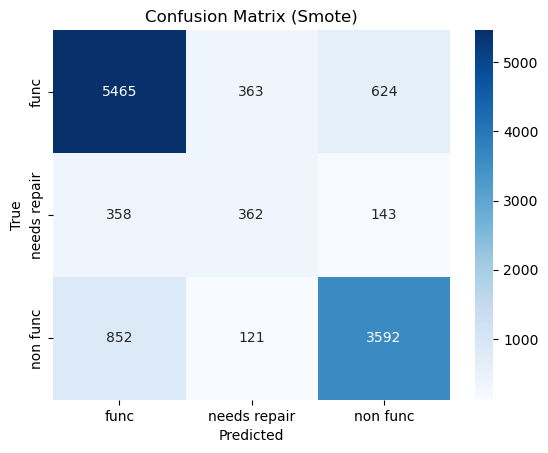

In [157]:
cm = confusion_matrix(y_val, y_pred_smote, labels=["functional", "functional needs repair", "non functional"])
sns.heatmap(cm, annot=True, fmt="d", xticklabels=['func', 'needs repair', 'non func'], yticklabels=['func', 'needs repair', 'non func'], cmap="Blues")
plt.title("Confusion Matrix (Smote)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Submition

In [158]:
# Test predictions (for submission)
X_test = test_df.drop(columns=["id"])
test_preds = rf_smote.predict(X_test)
submission = pd.DataFrame({
    "id": test_df["id"],
    "status_group": test_preds
})

submission.head()

,id,status_group
0,50785,non functional
1,51630,functional needs repair
2,17168,functional
3,45559,non functional
4,49871,functional


In [159]:
submission.to_csv("./data/submission.csv", index=False)
print("Submission file created: submission.csv\n")
print(submission.head())

Submission file created: submission.csv

      id             status_group
0  50785           non functional
1  51630  functional needs repair
2  17168               functional
3  45559           non functional
4  49871               functional


## Communication

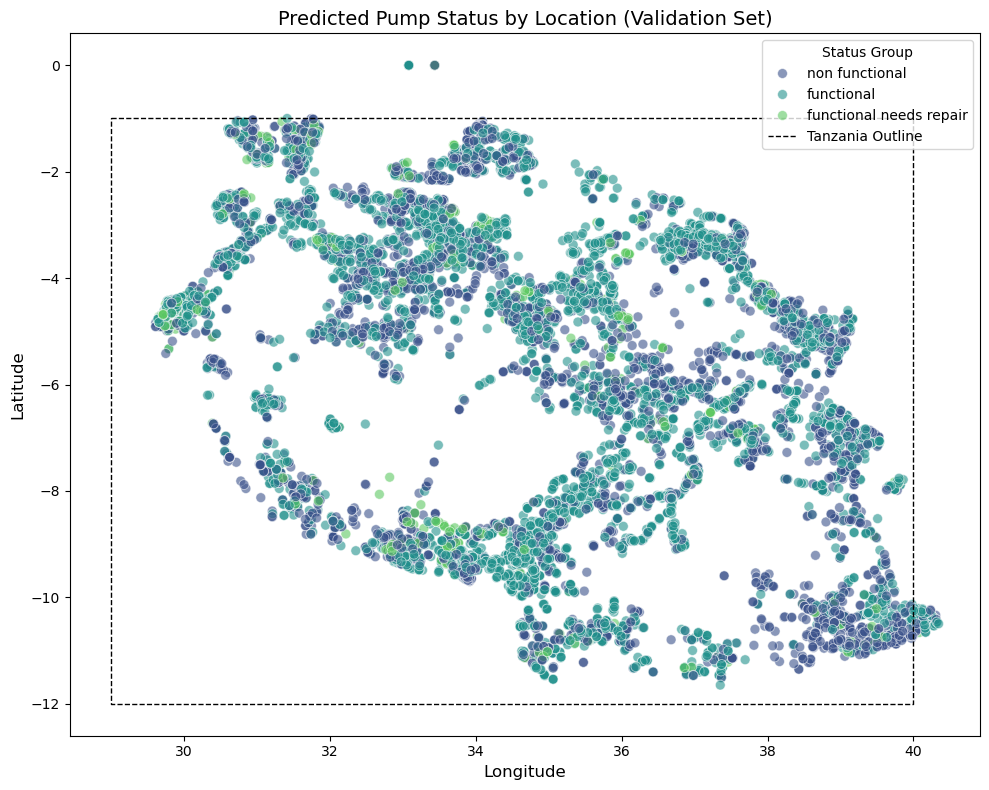

In [160]:
val_data = X_val[['longitude', 'latitude']].copy()
val_data['status_group'] = y_pred_smote

# Scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='longitude', y='latitude', hue='status_group', data=val_data, palette='viridis', alpha=0.6, s=50)
plt.title('Predicted Pump Status by Location (Validation Set)', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Rough Tanzania outline (approximate coordinates)
tanzania_border = {
    'longitude': [29, 40, 40, 29, 29],
    'latitude': [-1, -1, -12, -12, -1]
}
plt.plot(tanzania_border['longitude'], tanzania_border['latitude'], 'k--', linewidth=1, label='Tanzania Outline')

plt.legend(title='Status Group')
plt.tight_layout()
plt.savefig('map_predicted_status.png', dpi=300)
plt.show()

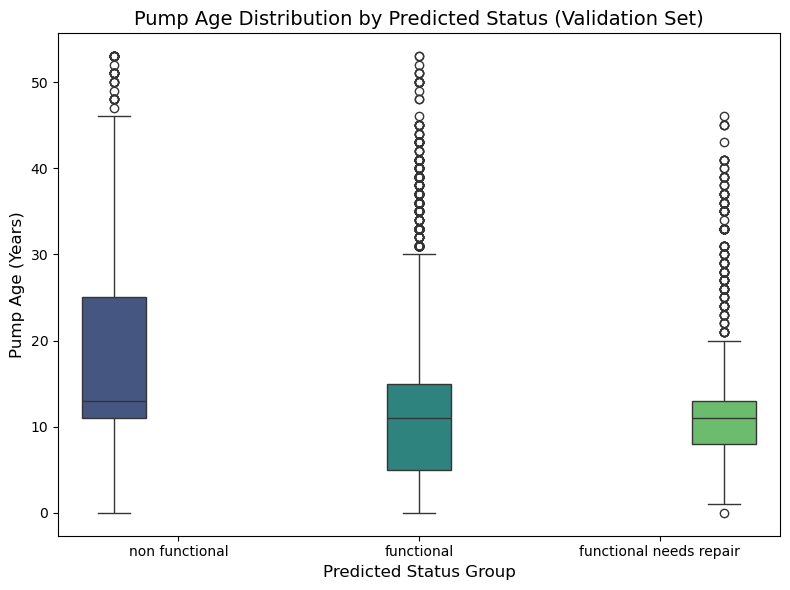

In [163]:
# Add pump_age and predictions to validation data
val_data['pump_age'] = X_val['pump_age']

plt.figure(figsize=(8, 6))
sns.boxplot(x='status_group', y='pump_age', data=val_data, palette='viridis', hue='status_group', dodge=True, legend=False)
plt.title('Pump Age Distribution by Predicted Status (Validation Set)', fontsize=14)
plt.xlabel('Predicted Status Group', fontsize=12)
plt.ylabel('Pump Age (Years)', fontsize=12)
plt.tight_layout()
plt.savefig('pump_age_vs_status.png', dpi=300)
plt.show()

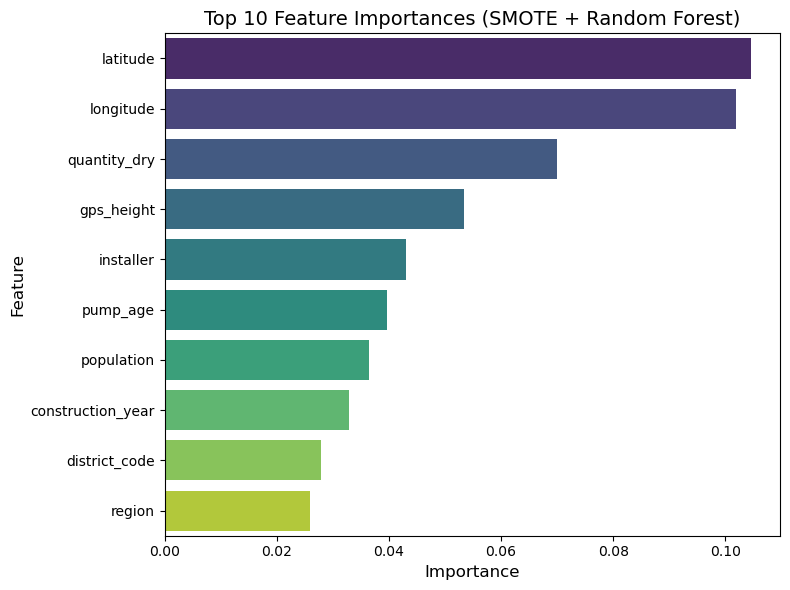

In [166]:
# Top 10 feature importances for smote model
top_10 = importances_smote.sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x='importance', y='feature', data=top_10, palette='viridis', hue="feature", legend=False)
plt.title('Top 10 Feature Importances (SMOTE + Random Forest)', fontsize=14)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=300)
plt.show()

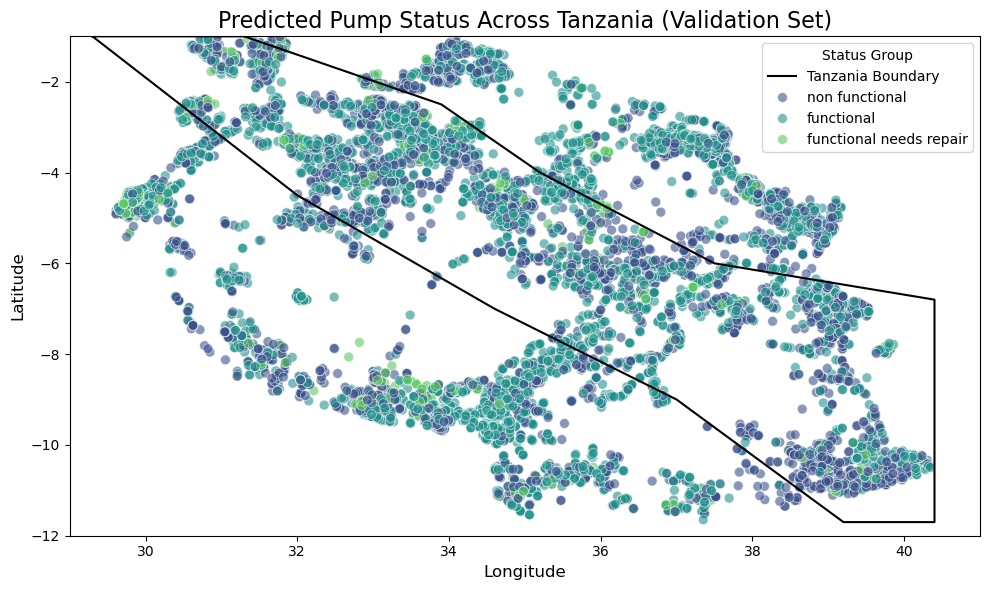

In [171]:
val_data = X_val[['longitude', 'latitude']].copy()
val_data['status_group'] = y_pred_smote

# Define a more detailed Tanzania outline (approximate, based on real coords)
tanzania_outline = {
    'longitude': [29.3, 31.3, 33.9, 35.2, 37.5, 40.4, 40.4, 39.2, 37.0, 34.6, 32.0, 29.3],
    'latitude': [-1.0, -1.0, -2.5, -4.0, -6.0, -6.8, -11.7, -11.7, -9.0, -7.0, -4.5, -1.0]
}

# Plot
plt.figure(figsize=(10, 6))
plt.plot(tanzania_outline['longitude'], tanzania_outline['latitude'], 'k-', linewidth=1.5, label='Tanzania Boundary')

# Scatter plot of predictions
sns.scatterplot(x='longitude', y='latitude', hue='status_group', data=val_data, 
                palette='viridis', alpha=0.6, s=50)

plt.title('Predicted Pump Status Across Tanzania (Validation Set)', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.xlim(29, 41)
plt.ylim(-12, -1)
plt.legend(title='Status Group', loc='upper right')
plt.tight_layout()
plt.savefig('tanzania_map_predicted_status_simple.png', dpi=300)
plt.show()

### Communication For Stakeholders

We’ve built a tool to predict the condition of water pumps across Tanzania, helping ensure more people get clean water. Using data on pump locations, age, and water flow, our model correctly identifies 79% of pump statuses; whether they’re working, need repairs, or are broken.
#### Key Insights:
- **Location Matters**: Pumps in dry central areas (like Dodoma) are more likely to fail, while those near lakes or rivers (like Lake Victoria) usually work well.
- **Age Counts**: Older pumps break down more often—many over 15 years old aren’t functioning.
- **Water Flow**: Pumps with no water flow are almost always broken.

Our tool flags 42% of pumps needing repairs (up from 35%), giving us a better shot at fixing them before they fail completely. Next steps could focus on checking pumps in dry zones and replacing the oldest ones to keep water flowing for more communities.